**Setup and Data Collection**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from xgboost import XGBRegressor

# Public URL for Big Mart Sales Dataset
data_url = "https://raw.githubusercontent.com/shrikant-temburwar/Big-Mart-Sales-Prediction/master/train.csv"
df = pd.read_csv(data_url)

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


**Data Cleaning & Preprocessing**

In [ ]:
# 1. Handling Missing Values
# Fill Item_Weight with the mean
df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)

# Fill Outlet_Size with the mode based on Outlet_Type
mode_of_outlet_size = df.pivot_table(values='Outlet_Size', columns='Outlet_Type', aggfunc=(lambda x: x.mode()[0]))
missing_values = df['Outlet_Size'].isnull()
df.loc[missing_values, 'Outlet_Size'] = df.loc[missing_values, 'Outlet_Type'].apply(lambda x: mode_of_outlet_size[x])

# 2. Fixing Inconsistent Categories
df.replace({'Item_Fat_Content': {'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'}}, inplace=True)

# 3. Label Encoding
encoder = LabelEncoder()
cat_cols = ['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

# Splitting Features and Target
X = df.drop(columns='Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

/tmp/ipykernel_12804/4158636772.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)


**Exploratory Data Analysis (EDA)**

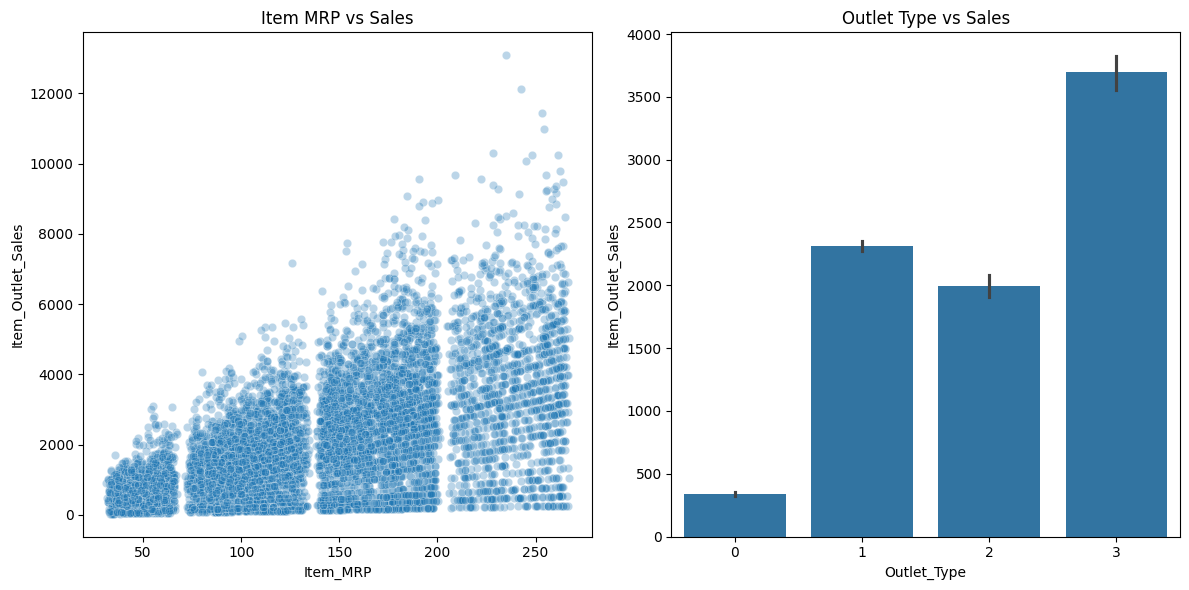

In [ ]:
plt.figure(figsize=(12,6))

# Item MRP vs Sales
plt.subplot(1, 2, 1)
sns.scatterplot(x='Item_MRP', y='Item_Outlet_Sales', data=df, alpha=0.3)
plt.title('Item MRP vs Sales')

# Outlet Type vs Sales
plt.subplot(1, 2, 2)
sns.barplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df)
plt.title('Outlet Type vs Sales')

plt.tight_layout()
plt.show()

**Model Training (XGBoost)**

In [ ]:
# Initialize and train the model
regressor = XGBRegressor(n_estimators=1000, learning_rate=0.05)
regressor.fit(X_train, y_train)

# Prediction on test data
test_data_prediction = regressor.predict(X_test)

# Evaluation
r2_score = metrics.r2_score(y_test, test_data_prediction)
rmse = np.sqrt(metrics.mean_squared_error(y_test, test_data_prediction))

print(f"R Squared Value: {r2_score:.4f}")
print(f"RMSE: {rmse:.2f}")

R Squared Value: 0.5081
RMSE: 1232.31


**Prediction System**

In [ ]:
# Example: Taking one row from the test set as a 'new' input
sample_input = X_test.iloc[0].values.reshape(1, -1)
predicted_sales = regressor.predict(sample_input)

print(f"Predicted Sales for this item: {predicted_sales[0]:.2f}")

Predicted Sales for this item: 2693.19
